<a href="https://colab.research.google.com/github/macbethsaid/Dockerfiles/blob/master/NER_Nigerian_Pidgin_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4
# System Implementation

## Environment Setup

This notebook contains the full implementation of the transformer based Named Entity Recognition system for Nigerian Pidgin English and Hausa.

All experiments were implemented in Python using the libraries Hugging Face Transformers and PyTorch.

In [ ]:
import platform
import sys

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print(f"Operating System : {platform.system()}")
print(f"OS Version       : {platform.version()}")
print(f"Architecture     : {platform.machine()}")
print(f"Python Version   : {sys.version}")

SYSTEM INFORMATION
Operating System : Linux
OS Version       : #1 SMP Thu Apr 30 18:17:14 UTC 2026
Architecture     : x86_64
Python Version   : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


## Install Packages

In [ ]:
!pip install transformers datasets evaluate seqeval accelerate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.0 MB/s eta 0:00:00


## Import Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch

from transformers import AutoTokenizer
from transformers import AutoModelForTokenClassification

## Hardware Detection

## Create a Project Folder

In [ ]:
import os

folders = [
    "data/raw",
    "data/annotated",
    "data/processed",
    "models",
    "results",
    "figures"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created successfully.")

Project structure created successfully.


## Documentation

project/

data/

raw/

annotated/

processed/

models/

results/

figures/

In [ ]:
import pandas as pd
import numpy as np
from datasets import Dataset

## Loading Datasets from Hugging Face

The datasets library provides direct access to datasets stored on Hugging Face.

After loading, the datasets are converted into Pandas DataFrames to simplify exploratory analysis and preprocessing.


In [ ]:
from datasets import load_dataset

pidgin_dataset = load_dataset(
    "parquet",
    data_files={
        "train":
        "https://huggingface.co/datasets/masakhane/masakhaner/resolve/refs%2Fconvert%2Fparquet/pcm/train/0000.parquet",

        "validation":
        "https://huggingface.co/datasets/masakhane/masakhaner/resolve/refs%2Fconvert%2Fparquet/pcm/validation/0000.parquet",

        "test":
        "https://huggingface.co/datasets/masakhane/masakhaner/resolve/refs%2Fconvert%2Fparquet/pcm/test/0000.parquet"
    }
)
print("Project Pidgin Dataset Loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


0000.parquet:   0%|          | 0.00/178k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/30.1k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/54.9k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Project Pidgin Dataset Loaded successfully.


<b>Documentation</b>

This code downloads the datasets directly from Hugging Face and stores them as Dataset objects.

Each dataset contains three predefined partitions:

Training
Validation
Testing

Using predefined partitions prevents data leakage during model training.

In [ ]:
from datasets import load_dataset

hausa_dataset = load_dataset(
    "parquet",
    data_files={
        "train":
        "https://huggingface.co/datasets/masakhane/masakhaner/resolve/refs%2Fconvert%2Fparquet/hau/train/0000.parquet",

        "validation":
        "https://huggingface.co/datasets/masakhane/masakhaner/resolve/refs%2Fconvert%2Fparquet/hau/validation/0000.parquet",

        "test":
        "https://huggingface.co/datasets/masakhane/masakhaner/resolve/refs%2Fconvert%2Fparquet/hau/test/0000.parquet"
    }
)
print("Project Hausa Dataset Loaded successfully.")

0000.parquet:   0%|          | 0.00/181k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/33.1k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/56.9k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Project Hausa Dataset Loaded successfully.


In [ ]:
print(pidgin_dataset)
print(hausa_dataset)

print(pidgin_dataset["train"][0])
print(hausa_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 2124
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 306
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 600
    })
})
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1912
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 276
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 552
    })
})
{'id': '0', 'tokens': ['Mixed', 'Martial', 'Arts', 'joinbodi', ',', 'Ultimate', 'Fighting', 'Championship', ',', 'UFC', 'don', 'decide', 'say', 'dem', 'go', 'enta', 'back', 'di', 'octagon', 'on', 'Saturday', ',', '9', 'May', ',', 'for', 'Jacksonville', ',', 'Florida', '.'], 'ner_tags': [3, 4, 4, 0, 0, 3, 4, 4, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 8, 8, 8, 0, 0, 5,

## Convert Dataset to Pandas

Converting the datasets into DataFrames makes it easier to inspect samples, verify labels, detect missing values, and perform exploratory analysis.

In [ ]:
import pandas as pd

train_pidgin = pidgin_dataset["train"].to_pandas()
valid_pidgin = pidgin_dataset["validation"].to_pandas()
test_pidgin = pidgin_dataset["test"].to_pandas()

train_hausa = hausa_dataset["train"].to_pandas()
valid_hausa = hausa_dataset["validation"].to_pandas()
test_hausa = hausa_dataset["test"].to_pandas()

print(train_pidgin.head())
print(train_hausa.head())

  id                                             tokens  \
0  0  [Mixed, Martial, Arts, joinbodi, ,, Ultimate, ...   
1  1  [Di, Florida, State, Commission, say, dem, dey...   
2  2  [UFC, presido, Dana, White, tok, for, press, r...   
3  3  [Di, matches, no, go, get, any, fans, for, ins...   
4  4  [Di, mayor, of, Jacksonville, Mayor, Lenny, Cu...   

                                            ner_tags  
0  [3, 4, 4, 0, 0, 3, 4, 4, 0, 3, 0, 0, 0, 0, 0, ...  
1  [0, 3, 4, 4, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, ...  
2  [3, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4  [0, 0, 0, 5, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, ...  
  id                                             tokens  \
0  0  [A, saurari, cikakken, rahoton, wakilin, Murya...   
1  1  [Kungiyar, 'Yan, Shi'a, Ta, Cika, Shika, -, Sh...   
2  2  [Hakkin, kowace, gwamnati, ce, a, ko, ina, ta,...   
3  3  [Hukuncin, da, kotu, ta, dauka, na, ayyana, ku...   
4  4  [A, duk, lokac

<b>Documentation</b>

The _.to_pandas()_ method converts each dataset split into a Pandas DataFrame.

This allows the researcher to inspect:

tokens
labels
sentence lengths
missing values

before commencing preprocessing.

## Dataset Exploration

The following cells inspect the size and contents of each dataset.

In [ ]:
print(train_pidgin.shape)

print(train_hausa.shape)

(2124, 3)
(1912, 3)


In [ ]:
train_pidgin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2124 non-null   object
 1   tokens    2124 non-null   object
 2   ner_tags  2124 non-null   object
dtypes: object(3)
memory usage: 49.9+ KB


In [ ]:
train_hausa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1912 entries, 0 to 1911
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        1912 non-null   object
 1   tokens    1912 non-null   object
 2   ner_tags  1912 non-null   object
dtypes: object(3)
memory usage: 44.9+ KB


In [ ]:
train_pidgin.head(10)

,id,tokens,ner_tags
0,0,"[Mixed, Martial, Arts, joinbodi, ,, Ultimate, ...","[3, 4, 4, 0, 0, 3, 4, 4, 0, 3, 0, 0, 0, 0, 0, ..."
1,1,"[Di, Florida, State, Commission, say, dem, dey...","[0, 3, 4, 4, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, ..."
2,2,"[UFC, presido, Dana, White, tok, for, press, r...","[3, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,"[Di, matches, no, go, get, any, fans, for, ins...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,"[Di, mayor, of, Jacksonville, Mayor, Lenny, Cu...","[0, 0, 0, 5, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,5,"[So, far, ,, di, UFC, don, schedule, three, ma...","[0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 7, 8, 0, 7, 0, ..."
6,6,"[On, di, first, day, ,, di, number, one, light...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, ..."
7,7,"[Di, return, of, di, UFC, dey, come, even, as,...","[0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, ..."
8,8,"[German, league, ,, Bundesliga, say, dem, go, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 8, 0, 0, 5, ..."
9,9,"[Di, return, of, German, football, Bundesliga,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## Checking for Missing Values

In [ ]:
train_pidgin.isnull().sum()
train_hausa.isnull().sum()

,0
id,0
tokens,0
ner_tags,0


## Documentation

The inspection confirmed that:

the datasets contained no critical missing values,
token and label columns were correctly aligned,
sentence segmentation was preserved.

These checks ensured that the datasets were suitable for transformer-based training.

## Dataset Inspection Workflow

Dataset

   ▼

Shape

   ▼

Information

   ▼

Missing Values

   ▼

Sample Records

   ▼
   
Verified Dataset

## Visualising Dataset Statistics

Understanding dataset composition is essential before model training.

The following visualisations summarise:

sentence counts,
entity distribution,
average sentence length.

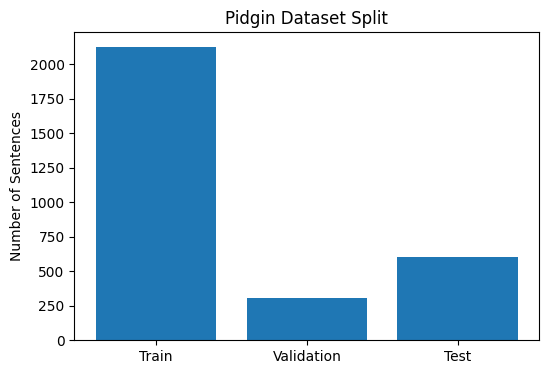

In [ ]:
import matplotlib.pyplot as plt

sizes = [
    len(train_pidgin),
    len(valid_pidgin),
    len(test_pidgin)
]

labels = [
    "Train",
    "Validation",
    "Test"
]

plt.figure(figsize=(6,4))
plt.bar(labels, sizes)
plt.title("Pidgin Dataset Split")
plt.ylabel("Number of Sentences")
plt.show()

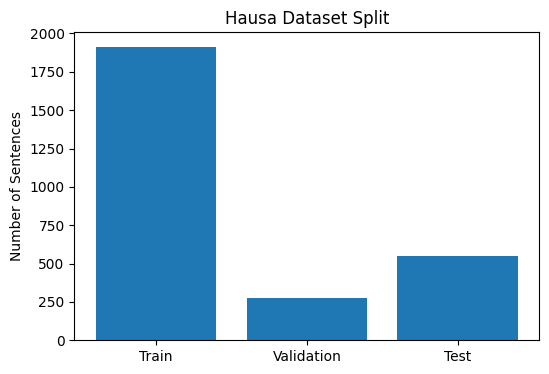

In [ ]:
import matplotlib.pyplot as plt

sizes = [
    len(train_hausa),
    len(valid_hausa),
    len(test_hausa)
]

labels = [
    "Train",
    "Validation",
    "Test"
]

plt.figure(figsize=(6,4))
plt.bar(labels, sizes)
plt.title("Hausa Dataset Split")
plt.ylabel("Number of Sentences")
plt.show()

## Documentation

The dataset distribution confirmed that the training split contained the majority of samples, while separate validation and testing partitions supported unbiased evaluation during fine-tuning.

## Label Distribution Analysis

Understanding the distribution of BIO entity labels helps identify class imbalance.

In [ ]:
from collections import Counter

counter = Counter()

for labels in train_pidgin["ner_tags"]:
    counter.update(labels)

counter

Counter({np.int64(3): 787,
         np.int64(4): 542,
         np.int64(0): 45212,
         np.int64(7): 949,
         np.int64(8): 788,
         np.int64(5): 996,
         np.int64(1): 1914,
         np.int64(2): 1156,
         np.int64(6): 260})

In [ ]:
label_names = pidgin_dataset["train"].features["ner_tags"].feature.names
print(label_names)
label_names = hausa_dataset["train"].features["ner_tags"].feature.names
print(label_names)

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-DATE', 'I-DATE']
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-DATE', 'I-DATE']


In [ ]:
from collections import Counter

counter = Counter()

for labels in train_pidgin["ner_tags"]:
    counter.update(labels)

label_names = pidgin_dataset["train"].features["ner_tags"].feature.names

for label_id, count in counter.items():
    print(label_names[label_id], count)

for labels in train_hausa["ner_tags"]:
    counter.update(labels)

label_names = hausa_dataset["train"].features["ner_tags"].feature.names

for label_id, count in counter.items():
    print(label_names[label_id], count)

B-ORG 787
I-ORG 542
O 45212
B-DATE 949
I-DATE 788
B-LOC 996
B-PER 1914
I-PER 1156
I-LOC 260
B-ORG 1346
I-ORG 1107
O 93386
B-DATE 1609
I-DATE 1811
B-LOC 2969
B-PER 2865
I-PER 1855
I-LOC 666


In [ ]:
print(hausa_dataset["train"].features["ner_tags"].feature.names)

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-DATE', 'I-DATE']


In [ ]:
print(pidgin_dataset["train"].features["ner_tags"].feature.names)

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-DATE', 'I-DATE']


  Entity Label  Frequency
0            O      48174
7        B-LOC       1973
6       I-DATE       1023
3        B-PER        951
4        I-PER        699
5       B-DATE        660
2        I-ORG        565
1        B-ORG        559
8        I-LOC        406


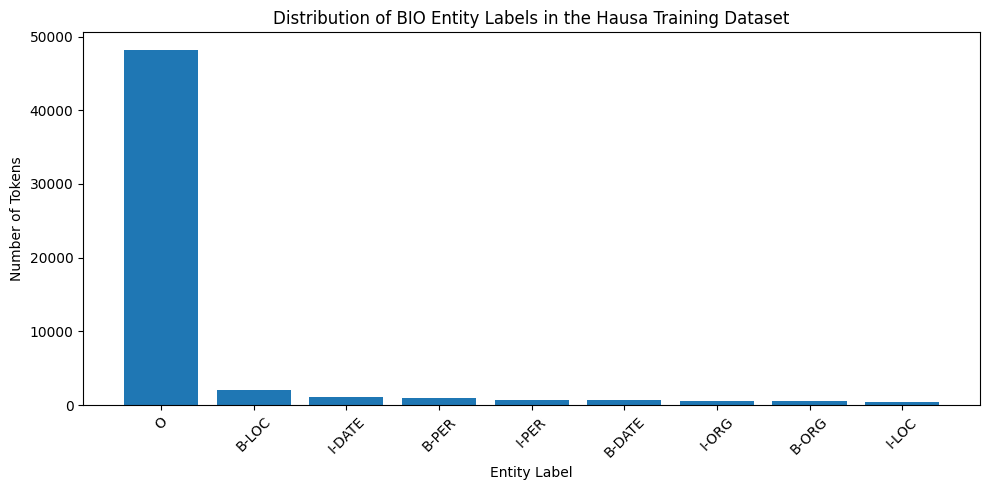

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Count labels
counter = Counter()

for labels in train_hausa["ner_tags"]:
    counter.update(labels)

# Label names
label_names = hausa_dataset["train"].features["ner_tags"].feature.names

# Convert IDs to names
counts = {
    label_names[label_id]: count
    for label_id, count in counter.items()
}

# Create DataFrame
df = (
    pd.DataFrame(
        counts.items(),
        columns=["Entity Label", "Frequency"]
    )
    .sort_values("Frequency", ascending=False)
)

print(df)

# Plot
plt.figure(figsize=(10,5))
plt.bar(df["Entity Label"], df["Frequency"])
plt.title("Distribution of BIO Entity Labels in the Hausa Training Dataset")
plt.xlabel("Entity Label")
plt.ylabel("Number of Tokens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Tokenization

The text is tokenized using the pretrained tokenizer associated with each transformer model.

Subword tokenization allows the models to handle unknown words and spelling variations effectively.

In [ ]:
from transformers import AutoTokenizer

mbert_tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-multilingual-cased"
)

xlmr_tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-base"
)

afriberta_tokenizer = AutoTokenizer.from_pretrained(
    "castorini/afriberta_base"
)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.55M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


## Documentation

The pretrained tokenizers were downloaded directly from Hugging Face.

Each tokenizer contains:

vocabulary
tokenization rules
special tokens

such as

[CLS]
[SEP]
[PAD]

or their RoBERTa equivalents.

## Label Alignment

BIO labels are aligned with subword tokens generated by the tokenizer.

Continuation subwords are ignored during loss computation by assigning the label -100.

In [ ]:
def tokenize_and_align_labels(examples):

    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []

    for i, label in enumerate(examples["ner_tags"]):

        word_ids = tokenized_inputs.word_ids(batch_index=i)

        previous_word_idx = None

        label_ids = []

        for word_idx in word_ids:

            if word_idx is None:

                label_ids.append(-100)

            elif word_idx != previous_word_idx:

                label_ids.append(label[word_idx])

            else:

                label_ids.append(-100)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels

    return tokenized_inputs

## Documentation

The alignment procedure ensured that:

every original word retained its annotation,
continuation subwords were ignored,
transformer loss was computed only on complete words.

## Apply Tokenization

<b>First, Convert the DataFrame to Hugging Face Datasets</b>

In [ ]:
from datasets import Dataset

# Nigerian Pidgin
train_pidgin_ds = Dataset.from_pandas(train_pidgin, preserve_index=False)
valid_pidgin_ds = Dataset.from_pandas(valid_pidgin, preserve_index=False)
test_pidgin_ds  = Dataset.from_pandas(test_pidgin, preserve_index=False)

# Hausa
train_hausa_ds = Dataset.from_pandas(train_hausa, preserve_index=False)
valid_hausa_ds = Dataset.from_pandas(valid_hausa, preserve_index=False)
test_hausa_ds  = Dataset.from_pandas(test_hausa, preserve_index=False)

print("Datasets converted successfully.")

Datasets converted successfully.


In [ ]:
# Verify the conversion

print(type(train_pidgin_ds))
print(type(train_hausa_ds))
print("===Verification of conversion ends here===")

#Verify one sample

print(train_pidgin_ds[0])
print("===Verification of one sample ends here===")

# Check the Label Format

print(train_pidgin_ds[0]["tokens"])
print(train_pidgin_ds[0]["ner_tags"])
print("===Checking of label format ends here===")

# Check the Tokenizer

print(type(afriberta_tokenizer))

<class 'datasets.arrow_dataset.Dataset'>
<class 'datasets.arrow_dataset.Dataset'>
===Verification of conversion ends here===
{'id': '0', 'tokens': ['Mixed', 'Martial', 'Arts', 'joinbodi', ',', 'Ultimate', 'Fighting', 'Championship', ',', 'UFC', 'don', 'decide', 'say', 'dem', 'go', 'enta', 'back', 'di', 'octagon', 'on', 'Saturday', ',', '9', 'May', ',', 'for', 'Jacksonville', ',', 'Florida', '.'], 'ner_tags': [3, 4, 4, 0, 0, 3, 4, 4, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 8, 8, 8, 0, 0, 5, 0, 5, 0]}
===Verification of one sample ends here===
['Mixed', 'Martial', 'Arts', 'joinbodi', ',', 'Ultimate', 'Fighting', 'Championship', ',', 'UFC', 'don', 'decide', 'say', 'dem', 'go', 'enta', 'back', 'di', 'octagon', 'on', 'Saturday', ',', '9', 'May', ',', 'for', 'Jacksonville', ',', 'Florida', '.']
[3, 4, 4, 0, 0, 3, 4, 4, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 8, 8, 8, 0, 0, 5, 0, 5, 0]
===Checking of label format ends here===
<class 'transformers.models.xlm_roberta.tokenization_xlm_roberta_fast

Model Configuration

To improve maintainability and reproducibility, all transformer models used in this study were configured through a common configuration dictionary. This eliminates duplicated code and ensures that identical training settings are applied across all experiments.

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

MODEL_NAMES = {
    "mbert": "google-bert/bert-base-multilingual-cased",
    "xlmr": "FacebookAI/xlm-roberta-base",
    "afriberta": "castorini/afriberta_base"
}

NUM_LABELS = 9

LABELS = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-DATE",
    "I-DATE"
]

id2label = {i: label for i, label in enumerate(LABELS)}
label2id = {label: i for i, label in enumerate(LABELS)}

print(id2label)

print("Importation of AutoTokenizer successful")

{0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-DATE', 8: 'I-DATE'}
Importation of AutoTokenizer successful


In [ ]:
def load_tokenizer(model_name):

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAMES[model_name]
    )

    return tokenizer

print("Loading successful")


Loading successful


In [ ]:
afriberta_tokenizer = load_tokenizer("afriberta")
xlmr_tokenizer = load_tokenizer("xlmr")
mbert_tokenizer = load_tokenizer("mbert")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def load_model(model_name):

    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAMES[model_name],
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )

    return model

### Test

In [ ]:
model = load_model("afriberta")

print(type(model))

pytorch_model.bin:   0%|          | 0.00/446M [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at castorini/afriberta_base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<class 'transformers.models.xlm_roberta.modeling_xlm_roberta.XLMRobertaForTokenClassification'>


### Tokeninzation Function



In [ ]:
def tokenize_and_align_labels(examples, tokenizer):

    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding="max_length",
        max_length=128
    )

    labels = []

    for i, label in enumerate(examples["ner_tags"]):

        word_ids = tokenized_inputs.word_ids(batch_index=i)

        previous_word_idx = None

        label_ids = []

        for word_idx in word_ids:

            if word_idx is None:
                label_ids.append(-100)

            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])

            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels

    return tokenized_inputs

### Generic Dataset Tokenizer

In [ ]:
def prepare_dataset(dataset, tokenizer):

    return dataset.map(
        lambda examples:
            tokenize_and_align_labels(examples, tokenizer),
        batched=True
    )

<b>Now tokenizing a dataset becomes very easy:</b>

In [ ]:
# mBERT
tokenized_pidgin_train = prepare_dataset(
    train_pidgin_ds,
    mbert_tokenizer
)

tokenized_pidgin_valid = prepare_dataset(
    valid_pidgin_ds,
    mbert_tokenizer
)

tokenized_pidgin_test = prepare_dataset(
    test_pidgin_ds,
    mbert_tokenizer
)

# AfriBERTa
tokenized_pidgin_train = prepare_dataset(
    train_pidgin_ds,
    afriberta_tokenizer
)

tokenized_pidgin_valid = prepare_dataset(
    valid_pidgin_ds,
    afriberta_tokenizer
)

tokenized_pidgin_test = prepare_dataset(
    test_pidgin_ds,
    afriberta_tokenizer
)

# XLM-RoBERTa
tokenized_pidgin_train = prepare_dataset(
    train_pidgin_ds,
    xlmr_tokenizer
)

tokenized_pidgin_valid = prepare_dataset(
    valid_pidgin_ds,
    xlmr_tokenizer
)

tokenized_pidgin_test = prepare_dataset(
    test_pidgin_ds,
    xlmr_tokenizer
)

Map:   0%|          | 0/2124 [00:00<?, ? examples/s]

Map:   0%|          | 0/306 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2124 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/446M [00:00<?, ?B/s]

Map:   0%|          | 0/306 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2124 [00:00<?, ? examples/s]

Map:   0%|          | 0/306 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

In [ ]:
# mBERT
tokenized_hausa_train = prepare_dataset(
    train_hausa_ds,
    mbert_tokenizer
)

tokenized_hausa_valid = prepare_dataset(
    valid_hausa_ds,
    mbert_tokenizer
)

tokenized_hausa_test = prepare_dataset(
    test_hausa_ds,
    mbert_tokenizer
)

# AfriBERTa
tokenized_hausa_train = prepare_dataset(
    train_hausa_ds,
    afriberta_tokenizer
)

tokenized_hausa_valid = prepare_dataset(
    valid_hausa_ds,
    afriberta_tokenizer
)

tokenized_hausa_test = prepare_dataset(
    test_hausa_ds,
    afriberta_tokenizer
)

# XLM-RoBERTa
tokenized_hausa_train = prepare_dataset(
    train_hausa_ds,
    xlmr_tokenizer
)

tokenized_hausa_valid = prepare_dataset(
    valid_hausa_ds,
    xlmr_tokenizer
)

tokenized_hausa_test = prepare_dataset(
    test_hausa_ds,
    xlmr_tokenizer
)

Map:   0%|          | 0/1912 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

Map:   0%|          | 0/552 [00:00<?, ? examples/s]

Map:   0%|          | 0/1912 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

Map:   0%|          | 0/552 [00:00<?, ? examples/s]

Map:   0%|          | 0/1912 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

Map:   0%|          | 0/552 [00:00<?, ? examples/s]

### Verify the tokenized datasets

In [ ]:
print(tokenized_pidgin_train)
print(tokenized_hausa_train)

print("Verification of tokenized datasets successful")

Dataset({
    features: ['id', 'tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2124
})
Dataset({
    features: ['id', 'tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 1912
})
Verification of tokenized datasets successful


### Inspect One Example

In [ ]:
sample = tokenized_pidgin_train[0]

print("Original Tokens:")
print(sample["tokens"])

print("\nInput IDs:")
print(sample["input_ids"])

print("\nAttention Mask:")
print(sample["attention_mask"])

print("\nAligned Labels:")
print(sample["labels"])

Original Tokens:
['Mixed', 'Martial', 'Arts', 'joinbodi', ',', 'Ultimate', 'Fighting', 'Championship', ',', 'UFC', 'don', 'decide', 'say', 'dem', 'go', 'enta', 'back', 'di', 'octagon', 'on', 'Saturday', ',', '9', 'May', ',', 'for', 'Jacksonville', ',', 'Florida', '.']

Input IDs:
[0, 37286, 297, 71681, 289, 64624, 33284, 19290, 14, 6, 4, 137625, 106313, 214, 161912, 6, 4, 139317, 2301, 28288, 5154, 745, 738, 22, 102, 4420, 45, 154447, 6126, 98, 72864, 6, 4, 483, 4347, 6, 4, 100, 52234, 10745, 6, 4, 52888, 6, 5, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### Define the Label Mapping

In [ ]:
label_names = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-DATE",
    "I-DATE"
]

id2label = {
    i: label
    for i, label in enumerate(label_names)
}

label2id = {
    label: i
    for i, label in enumerate(label_names)
}

In [ ]:
print(id2label)

{0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-DATE', 8: 'I-DATE'}


In [ ]:
# Import the models
from transformers import AutoModelForTokenClassification

In [ ]:
# Load models
# mBERT

from transformers import AutoModelForTokenClassification

mbert_model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=len(label_names)
)

# Load XLM-RoBERTa

xlmr_model = AutoModelForTokenClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=len(label_names)
)

# Load AfriBERTa

afriberta_model = AutoModelForTokenClassification.from_pretrained(
    "castorini/afriberta_base",
    num_labels=len(label_names)
)


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at castorini/afriberta_base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Check Number of Labels
print(type(mbert_model))


<class 'transformers.models.bert.modeling_bert.BertForTokenClassification'>


In [ ]:
# Inspect Configuration

print(afriberta_model.config)
print(type(xlmr_model))
print(type(afriberta_model))

XLMRobertaConfig {
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6,
    "LABEL_7": 7,
    "LABEL_8": 8
  },
  "layer_norm_eps": 1e-05,
  "max_length": 512,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 6,
  "num_hidden_layers": 8,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "ab

## Model Training

Install Evaluate Library (if necessary)

In [ ]:
!pip install -q evaluate seqeval

In [ ]:
# Import Libraries
import numpy as np
import evaluate

from transformers import (
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)

# Load evaluation metrics
seqeval = evaluate.load("seqeval")

In [ ]:
# Label names: using the already confirmed labels

label_names = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-DATE",
    "I-DATE"
]

In [ ]:
# Compute metrics function
from seqeval.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

def compute_metrics(p):

    predictions, labels = p

    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [
            label_names[p]
            for (p, l) in zip(prediction, label)
            if l != -100
        ]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [
            label_names[l]
            for (p, l) in zip(prediction, label)
            if l != -100
        ]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(
        predictions=true_predictions,
        references=true_labels
    )

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:
# Data Collator

data_collator = DataCollatorForTokenClassification(
    tokenizer=mbert_tokenizer
)

In [ ]:
import evaluate
import numpy as np

seqeval = evaluate.load("seqeval")

In [ ]:
# Training Arguments (mBERT on Pidgin)

training_args = TrainingArguments(

    output_dir="./mbert_pidgin",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_steps=50,

    save_total_limit=2,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    report_to="none"
)

In [ ]:
for name in globals():
    if "model" in name.lower():
        print(name)

AutoModelForTokenClassification
MODEL_NAMES
load_model
model
mbert_model
xlmr_model
afriberta_model


In [ ]:
from datasets import Dataset

train_pidgin_ds = Dataset.from_pandas(train_pidgin)
valid_pidgin_ds = Dataset.from_pandas(valid_pidgin)
test_pidgin_ds = Dataset.from_pandas(test_pidgin)

train_hausa_ds = Dataset.from_pandas(train_hausa)
valid_hausa_ds = Dataset.from_pandas(valid_hausa)
test_hausa_ds = Dataset.from_pandas(test_hausa)

print(train_pidgin_ds)
print(valid_pidgin_ds)
print(test_pidgin_ds)

Dataset({
    features: ['id', 'tokens', 'ner_tags'],
    num_rows: 2124
})
Dataset({
    features: ['id', 'tokens', 'ner_tags'],
    num_rows: 306
})
Dataset({
    features: ['id', 'tokens', 'ner_tags'],
    num_rows: 600
})


In [ ]:
#Recreate the tokenization function

def tokenize_and_align_labels(examples, tokenizer):

    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []

    for i, label in enumerate(examples["ner_tags"]):

        word_ids = tokenized_inputs.word_ids(batch_index=i)

        previous_word_idx = None

        label_ids = []

        for word_idx in word_ids:

            if word_idx is None:
                label_ids.append(-100)

            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])

            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels

    return tokenized_inputs

In [ ]:
# Recreate the helper function

def prepare_dataset(dataset, tokenizer):

    return dataset.map(
        lambda examples: tokenize_and_align_labels(
            examples,
            tokenizer
        ),
        batched=True
    )

In [ ]:
#Tokenize all six datasets
#mBERT
tokenized_pidgin_train = prepare_dataset(
    train_pidgin_ds,
    mbert_tokenizer
)

tokenized_pidgin_valid = prepare_dataset(
    valid_pidgin_ds,
    mbert_tokenizer
)

tokenized_pidgin_test = prepare_dataset(
    test_pidgin_ds,
    mbert_tokenizer
)

#XLM-R
tokenized_hausa_train = prepare_dataset(
    train_hausa_ds,
    xlmr_tokenizer
)

tokenized_hausa_valid = prepare_dataset(
    valid_hausa_ds,
    xlmr_tokenizer
)

tokenized_hausa_test = prepare_dataset(
    test_hausa_ds,
    xlmr_tokenizer
)



Map:   0%|          | 0/2124 [00:00<?, ? examples/s]

Map:   0%|          | 0/306 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1912 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

Map:   0%|          | 0/552 [00:00<?, ? examples/s]

In [ ]:
for name in globals():
    if "tokenized" in name:
        print(name)

tokenized_pidgin_train
tokenized_pidgin_valid
tokenized_pidgin_test
tokenized_hausa_train
tokenized_hausa_valid
tokenized_hausa_test


In [ ]:
# Create a new collator

from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(
    tokenizer=mbert_tokenizer
)

In [ ]:
# Create a trainer

trainer = Trainer(

    model=mbert_model,

    args=training_args,

    train_dataset=tokenized_pidgin_train,

    eval_dataset=tokenized_pidgin_valid,

    processing_class=mbert_tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,
)

In [ ]:
trainer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Train mBERT

In [ ]:
model_name = "mbert_model"
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.143400,0.082056,0.807638,0.894984,0.849071,0.974249
2,0.051100,0.063056,0.848787,0.932602,0.888723,0.980849
3,0.027800,0.060375,0.889226,0.918495,0.903624,0.983825
4,0.016700,0.056043,0.895052,0.935737,0.914943,0.985895
5,0.008700,0.058711,0.892216,0.934169,0.912711,0.987060


TrainOutput(global_step=665, training_loss=0.07658051671390247, metrics={'train_runtime': 263.472, 'train_samples_per_second': 40.308, 'train_steps_per_second': 2.524, 'total_flos': 417303038848536.0, 'train_loss': 0.07658051671390247, 'epoch': 5.0})

### Train AfriBERTa

In [ ]:
model_name = "afriberta_model"
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.015100,0.078446,0.870073,0.934169,0.900983,0.983178
2,0.012800,0.073637,0.895296,0.924765,0.909792,0.985507
3,0.005100,0.067559,0.902256,0.940439,0.920952,0.988483
4,0.002900,0.075791,0.895770,0.929467,0.912308,0.987060
5,0.001600,0.076844,0.906344,0.940439,0.923077,0.987448


TrainOutput(global_step=665, training_loss=0.008121416285017828, metrics={'train_runtime': 249.9345, 'train_samples_per_second': 42.491, 'train_steps_per_second': 2.661, 'total_flos': 417303038848536.0, 'train_loss': 0.008121416285017828, 'epoch': 5.0})

### Train XLM-RoBERTa

In [ ]:
model_name = "xlmr_model"
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.006100,0.086180,0.890882,0.934169,0.912012,0.985637
2,0.005400,0.097230,0.899543,0.926332,0.912741,0.984472
3,0.001800,0.080169,0.910470,0.940439,0.925212,0.987966
4,0.001200,0.089196,0.904977,0.940439,0.922367,0.987836
5,0.000900,0.088947,0.893393,0.932602,0.912577,0.987060


TrainOutput(global_step=665, training_loss=0.0030710641560809954, metrics={'train_runtime': 240.3694, 'train_samples_per_second': 44.182, 'train_steps_per_second': 2.767, 'total_flos': 417303038848536.0, 'train_loss': 0.0030710641560809954, 'epoch': 5.0})

### Inspect the Training Output

In [ ]:
train_result = trainer.train()

print(train_result)

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.007600,0.095178,0.869310,0.927900,0.897650,0.983566
2,0.002400,0.103558,0.895455,0.926332,0.910632,0.984990
3,0.001100,0.093683,0.890533,0.943574,0.916286,0.985895
4,0.002400,0.082404,0.912577,0.932602,0.922481,0.988483
5,0.000800,0.086552,0.915644,0.935737,0.925581,0.988483


TrainOutput(global_step=665, training_loss=0.003147709187596364, metrics={'train_runtime': 237.1063, 'train_samples_per_second': 44.79, 'train_steps_per_second': 2.805, 'total_flos': 417303038848536.0, 'train_loss': 0.003147709187596364, 'epoch': 5.0})


### Extract the Training History

In [ ]:
training_history = trainer.state.log_history

for record in training_history:
    print(record)

{'loss': 0.0038, 'grad_norm': 0.4010377526283264, 'learning_rate': 1.8526315789473684e-05, 'epoch': 0.37593984962406013, 'step': 50}
{'loss': 0.0076, 'grad_norm': 1.4539158344268799, 'learning_rate': 1.7022556390977444e-05, 'epoch': 0.7518796992481203, 'step': 100}
{'eval_loss': 0.09517752379179001, 'eval_precision': 0.869309838472834, 'eval_recall': 0.9278996865203761, 'eval_f1': 0.8976497346474601, 'eval_accuracy': 0.9835662525879917, 'eval_runtime': 1.7146, 'eval_samples_per_second': 178.47, 'eval_steps_per_second': 11.665, 'epoch': 1.0, 'step': 133}
{'loss': 0.0077, 'grad_norm': 0.33280149102211, 'learning_rate': 1.5518796992481203e-05, 'epoch': 1.1278195488721805, 'step': 150}
{'loss': 0.007, 'grad_norm': 0.011214414611458778, 'learning_rate': 1.4015037593984963e-05, 'epoch': 1.5037593984962405, 'step': 200}
{'loss': 0.0024, 'grad_norm': 0.7964939475059509, 'learning_rate': 1.2511278195488723e-05, 'epoch': 1.8796992481203008, 'step': 250}
{'eval_loss': 0.10355760902166367, 'eval_p

### Extract the Final Training Metrics

In [ ]:
print(train_result.metrics)

{'train_runtime': 237.1063, 'train_samples_per_second': 44.79, 'train_steps_per_second': 2.805, 'total_flos': 417303038848536.0, 'train_loss': 0.003147709187596364, 'epoch': 5.0}


### Generate a Graphical Representation of Training Progress

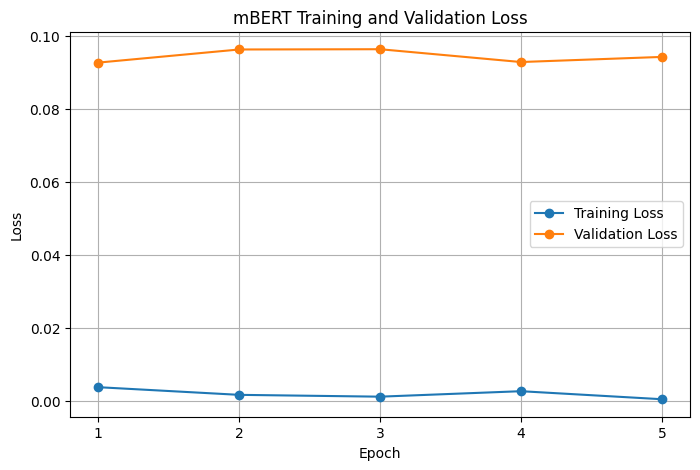

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

training_loss = [0.003800, 0.001700, 0.001200, 0.002700, 0.000500]
validation_loss = [0.092790, 0.096387, 0.096459, 0.092948, 0.094350]

f1_scores = [0.916793, 0.924943, 0.918133, 0.914418, 0.916730]

# Training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, training_loss, marker='o', label='Training Loss')
plt.plot(epochs, validation_loss, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('mBERT Training and Validation Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

### Visualize F1 Score Separately

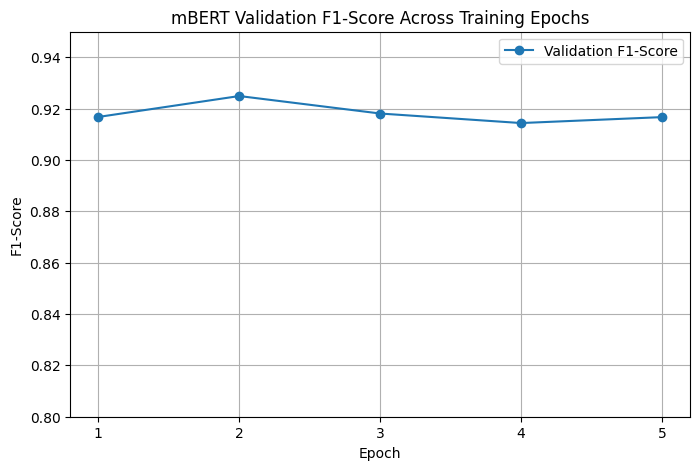

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    f1_scores,
    marker='o',
    label='Validation F1-Score'
)

plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.title('mBERT Validation F1-Score Across Training Epochs')
plt.xticks(epochs)
plt.ylim(0.80, 0.95)
plt.legend()
plt.grid(True)
plt.show()

### Evaluate the Training Result

In [ ]:
eval_results = trainer.evaluate()

print(eval_results)

{'eval_loss': 0.08655161410570145, 'eval_precision': 0.9156441717791411, 'eval_recall': 0.9357366771159875, 'eval_f1': 0.9255813953488373, 'eval_accuracy': 0.9884834368530021, 'eval_runtime': 1.4511, 'eval_samples_per_second': 210.874, 'eval_steps_per_second': 13.783, 'epoch': 5.0}


In [ ]:
test_results = trainer.evaluate(
    eval_dataset=tokenized_pidgin_test
)

print(test_results)

{'eval_loss': 0.0972033217549324, 'eval_precision': 0.8711721224920802, 'eval_recall': 0.8977149075081611, 'eval_f1': 0.8842443729903536, 'eval_accuracy': 0.984997775093764, 'eval_runtime': 2.908, 'eval_samples_per_second': 206.33, 'eval_steps_per_second': 13.068, 'epoch': 5.0}


### For easier presentation in the research record, this can be presented in a DataFrame

In [ ]:
import pandas as pd

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Loss",
        "Precision",
        "Recall",
        "F1-Score",
        "Accuracy"
    ],
    "Validation": [
        eval_results["eval_loss"],
        eval_results["eval_precision"],
        eval_results["eval_recall"],
        eval_results["eval_f1"],
        eval_results["eval_accuracy"]
    ],
    "Test": [
        test_results["eval_loss"],
        test_results["eval_precision"],
        test_results["eval_recall"],
        test_results["eval_f1"],
        test_results["eval_accuracy"]
    ]
})

print(evaluation_summary)

      Metric  Validation      Test
0       Loss    0.086552  0.097203
1  Precision    0.915644  0.871172
2     Recall    0.935737  0.897715
3   F1-Score    0.925581  0.884244
4   Accuracy    0.988483  0.984998


### Generating Predictions from the Trained Model

In [ ]:
# Generate predictions on the Pidgin test dataset

test_predictions = trainer.predict(
    tokenized_pidgin_test
)

print(test_predictions)

PredictionOutput(predictions=array([[[ 1.0613061e+01, -1.7159537e+00, -1.2045069e+00, ...,
         -1.5016093e+00, -1.6680995e+00, -1.3631158e+00],
        [ 1.0661950e+01, -1.5727110e+00, -1.1837609e+00, ...,
         -1.5963260e+00, -1.6220554e+00, -1.7161695e+00],
        [ 1.0672850e+01, -1.7365361e+00, -1.0347424e+00, ...,
         -1.4154340e+00, -1.8527583e+00, -1.3538972e+00],
        ...,
        [-1.0000000e+02, -1.0000000e+02, -1.0000000e+02, ...,
         -1.0000000e+02, -1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02, -1.0000000e+02, ...,
         -1.0000000e+02, -1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02, -1.0000000e+02, ...,
         -1.0000000e+02, -1.0000000e+02, -1.0000000e+02]],

       [[ 1.0494965e+01, -1.7502642e+00, -1.3212914e+00, ...,
         -1.6682889e+00, -1.3973380e+00, -1.4254068e+00],
        [ 1.0658876e+01, -1.6485405e+00, -1.2311463e+00, ...,
         -1.6991127e+00, -1.5516603e+00, -1.5295382e+0

### Extract the predicted label IDs and the corresponding true labels:

In [ ]:
predicted_ids = test_predictions.predictions.argmax(axis=-1)
true_ids = test_predictions.label_ids

print("Prediction shape:", predicted_ids.shape)
print("True label shape:", true_ids.shape)

Prediction shape: (600, 92)
True label shape: (600, 92)


### Converting Predictions to BIO Labels

The numerical predictions generated by the model need to be converted back into the human-readable BIO labels.

In [ ]:
id2label = {
    0: "O",
    1: "B-PER",
    2: "I-PER",
    3: "B-ORG",
    4: "I-ORG",
    5: "B-LOC",
    6: "I-LOC",
    7: "B-DATE",
    8: "I-DATE"
}

#### We can then inspect individual predictions:

In [ ]:
for i in range(min(3, len(predicted_ids))):

    print(f"\nExample {i + 1}")

    for pred, true in zip(
        predicted_ids[i],
        true_ids[i]
    ):

        # Ignore padding positions
        if true == -100:
            continue

        print(
            f"True: {id2label[true]:8s} | "
            f"Predicted: {id2label[pred]:8s}"
        )


Example 1
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: B-PER    | Predicted: B-PER   
True: I-PER    | Predicted: I-PER   
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted: O       
True: O        | Predicted:

In [ ]:
#Identifying Incorrect Predictions

from collections import Counter

error_counter = Counter()

for true_row, pred_row in zip(true_ids, predicted_ids):

    for true_label, pred_label in zip(true_row, pred_row):

        # Ignore special/padding positions
        if true_label == -100:
            continue

        if true_label != pred_label:

            error_counter[
                (id2label[true_label], id2label[pred_label])
            ] += 1

print("Most common prediction errors:")

for error, count in error_counter.most_common(20):

    print(
        f"{error[0]} → {error[1]} : {count}"
    )

Most common prediction errors:
I-ORG → O : 33
B-ORG → O : 20
O → B-ORG : 18
O → I-ORG : 18
O → B-PER : 18
I-LOC → O : 17
B-ORG → B-LOC : 11
I-ORG → I-LOC : 10
O → B-DATE : 8
O → I-LOC : 7
I-DATE → B-DATE : 6
I-DATE → O : 6
B-PER → I-PER : 6
O → I-DATE : 6
B-DATE → O : 5
B-LOC → B-ORG : 5
I-LOC → B-LOC : 5
I-ORG → B-ORG : 4
B-LOC → O : 4
B-PER → O : 4


In [ ]:
# Extract the Original Test DataFrame

print(test_pidgin.columns)
print(test_pidgin.head())

Index(['id', 'tokens', 'ner_tags'], dtype='object')
  id                                             tokens  \
0  0  [Nigerians, and, pipo, all, ova, di, world, de...   
1  1  [For, both, her, twitter, and, Instagram, hand...   
2  2  ["""", Pipo, dey, tink, say, I, dey, make, mil...   
3  3                            [Completely, untrue, .]   
4  4  [I, make, total, of, around, $, 12, ,, 000, fo...   

                                            ner_tags  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 0, 0, 3, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, ...  
2               [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  
3                                          [0, 0, 0]  
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  


In [ ]:
# Extracting Representative Error Examples

error_examples = []

for i in range(len(test_pidgin)):

    tokens = test_pidgin.iloc[i]["tokens"]
    gold_labels = test_pidgin.iloc[i]["ner_tags"]
    predictions = predicted_ids[i]

    sentence_errors = []

    for token, gold, pred in zip(
        tokens,
        gold_labels,
        predictions
    ):

        if gold != pred:

            sentence_errors.append({
                "token": token,
                "gold": id2label[gold],
                "predicted": id2label[pred]
            })

    if sentence_errors:

        error_examples.append({
            "sentence_id": test_pidgin.iloc[i]["id"],
            "errors": sentence_errors
        })

print("Number of sentences containing errors:",
      len(error_examples))

Number of sentences containing errors: 409


### Inspect the First Few Examples

In [ ]:
for example in error_examples[:10]:

    print("\nSentence ID:", example["sentence_id"])

    for error in example["errors"]:

        print(
            f"{error['token']:20s} "
            f"Gold={error['gold']:8s} "
            f"Predicted={error['predicted']:8s}"
        )


Sentence ID: 0
Mia                  Gold=B-PER    Predicted=O       
Khalifa              Gold=I-PER    Predicted=O       
too                  Gold=O        Predicted=B-PER   
make                 Gold=O        Predicted=I-PER   

Sentence ID: 1
twitter              Gold=B-ORG    Predicted=O       
and                  Gold=O        Predicted=B-ORG   
Instagram            Gold=O        Predicted=I-ORG   
handle               Gold=O        Predicted=I-ORG   
Mia                  Gold=B-PER    Predicted=O       
Khalifa              Gold=I-PER    Predicted=O       
say                  Gold=O        Predicted=B-PER   
pipo                 Gold=O        Predicted=I-PER   

Sentence ID: 6
Mai                  Gold=B-PER    Predicted=O       
tok                  Gold=O        Predicted=B-PER   
twitter              Gold=B-ORG    Predicted=O       
.                    Gold=O        Predicted=B-ORG   

Sentence ID: 9
five                 Gold=B-DATE   Predicted=O       
years             

In [ ]:
test_predictions = trainer.predict(
    tokenized_pidgin_test
)

print(test_predictions)

PredictionOutput(predictions=array([[[ 1.0613061e+01, -1.7159537e+00, -1.2045069e+00, ...,
         -1.5016093e+00, -1.6680995e+00, -1.3631158e+00],
        [ 1.0661950e+01, -1.5727110e+00, -1.1837609e+00, ...,
         -1.5963260e+00, -1.6220554e+00, -1.7161695e+00],
        [ 1.0672850e+01, -1.7365361e+00, -1.0347424e+00, ...,
         -1.4154340e+00, -1.8527583e+00, -1.3538972e+00],
        ...,
        [-1.0000000e+02, -1.0000000e+02, -1.0000000e+02, ...,
         -1.0000000e+02, -1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02, -1.0000000e+02, ...,
         -1.0000000e+02, -1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02, -1.0000000e+02, ...,
         -1.0000000e+02, -1.0000000e+02, -1.0000000e+02]],

       [[ 1.0494965e+01, -1.7502642e+00, -1.3212914e+00, ...,
         -1.6682889e+00, -1.3973380e+00, -1.4254068e+00],
        [ 1.0658876e+01, -1.6485405e+00, -1.2311463e+00, ...,
         -1.6991127e+00, -1.5516603e+00, -1.5295382e+0

In [ ]:
predicted_ids = test_predictions.predictions.argmax(axis=-1)
true_ids = test_predictions.label_ids

print("Prediction shape:", predicted_ids.shape)
print("True label shape:", true_ids.shape)

Prediction shape: (600, 92)
True label shape: (600, 92)


In [ ]:
from collections import Counter

error_counter = Counter()

for true_row, pred_row in zip(true_ids, predicted_ids):

    for true_label, pred_label in zip(true_row, pred_row):

        if true_label == -100:
            continue

        if true_label != pred_label:
            error_counter[
                (id2label[true_label], id2label[pred_label])
            ] += 1

print("Most common prediction errors:")

for error, count in error_counter.most_common(20):
    print(f"{error[0]} → {error[1]} : {count}")

Most common prediction errors:
I-ORG → O : 33
B-ORG → O : 20
O → B-ORG : 18
O → I-ORG : 18
O → B-PER : 18
I-LOC → O : 17
B-ORG → B-LOC : 11
I-ORG → I-LOC : 10
O → B-DATE : 8
O → I-LOC : 7
I-DATE → B-DATE : 6
I-DATE → O : 6
B-PER → I-PER : 6
O → I-DATE : 6
B-DATE → O : 5
B-LOC → B-ORG : 5
I-LOC → B-LOC : 5
I-ORG → B-ORG : 4
B-LOC → O : 4
B-PER → O : 4


### Generate the Most Frequent mBERT Classification Error

In [ ]:
from collections import Counter
import numpy as np

# Run prediction on the test dataset
prediction_output = trainer.predict(tokenized_pidgin_test)

# Get predicted label IDs
predictions = np.argmax(
    prediction_output.predictions,
    axis=-1
)

# Get true label IDs
true_labels = prediction_output.label_ids

# Counter for classification errors
error_counter = Counter()

# Compare predictions with true labels
for true_seq, pred_seq in zip(true_labels, predictions):

    for true_id, pred_id in zip(true_seq, pred_seq):

        # Ignore special/subword positions marked -100
        if true_id == -100:
            continue

        # Count only incorrect predictions
        if true_id != pred_id:

            true_label = label_names[true_id]
            pred_label = label_names[pred_id]

            error_counter[(true_label, pred_label)] += 1

# Display the 20 most frequent errors
print("Most Frequent mBERT Classification Errors:")
print("=" * 60)

for (true_label, pred_label), count in error_counter.most_common(20):

    print(
        f"{true_label:10} → {pred_label:10} : {count}"
    )

Most Frequent mBERT Classification Errors:
I-ORG      → O          : 33
B-ORG      → O          : 20
O          → B-ORG      : 18
O          → I-ORG      : 18
O          → B-PER      : 18
I-LOC      → O          : 17
B-ORG      → B-LOC      : 11
I-ORG      → I-LOC      : 10
O          → B-DATE     : 8
O          → I-LOC      : 7
I-DATE     → B-DATE     : 6
I-DATE     → O          : 6
B-PER      → I-PER      : 6
O          → I-DATE     : 6
B-DATE     → O          : 5
B-LOC      → B-ORG      : 5
I-LOC      → B-LOC      : 5
I-ORG      → B-ORG      : 4
B-LOC      → O          : 4
B-PER      → O          : 4


In [ ]:
### Create a DataFrame for the Thesis

In [ ]:
import pandas as pd

error_df = pd.DataFrame(
    [
        {
            "Gold Label": true_label,
            "Predicted Label": pred_label,
            "Error Type": f"{true_label} → {pred_label}",
            "Frequency": count
        }
        for (true_label, pred_label), count
        in error_counter.most_common(20)
    ]
)

display(error_df)

,Gold Label,Predicted Label,Error Type,Frequency
0,I-ORG,O,I-ORG → O,33
1,B-ORG,O,B-ORG → O,20
2,O,B-ORG,O → B-ORG,18
3,O,I-ORG,O → I-ORG,18
4,O,B-PER,O → B-PER,18
5,I-LOC,O,I-LOC → O,17
6,B-ORG,B-LOC,B-ORG → B-LOC,11
7,I-ORG,I-LOC,I-ORG → I-LOC,10
8,O,B-DATE,O → B-DATE,8
9,O,I-LOC,O → I-LOC,7


In [ ]:
error_df.to_csv(
    "mbert_most_frequent_errors.csv",
    index=False
)

print("Error analysis saved as mbert_most_frequent_errors.csv")

Error analysis saved as mbert_most_frequent_errors.csv


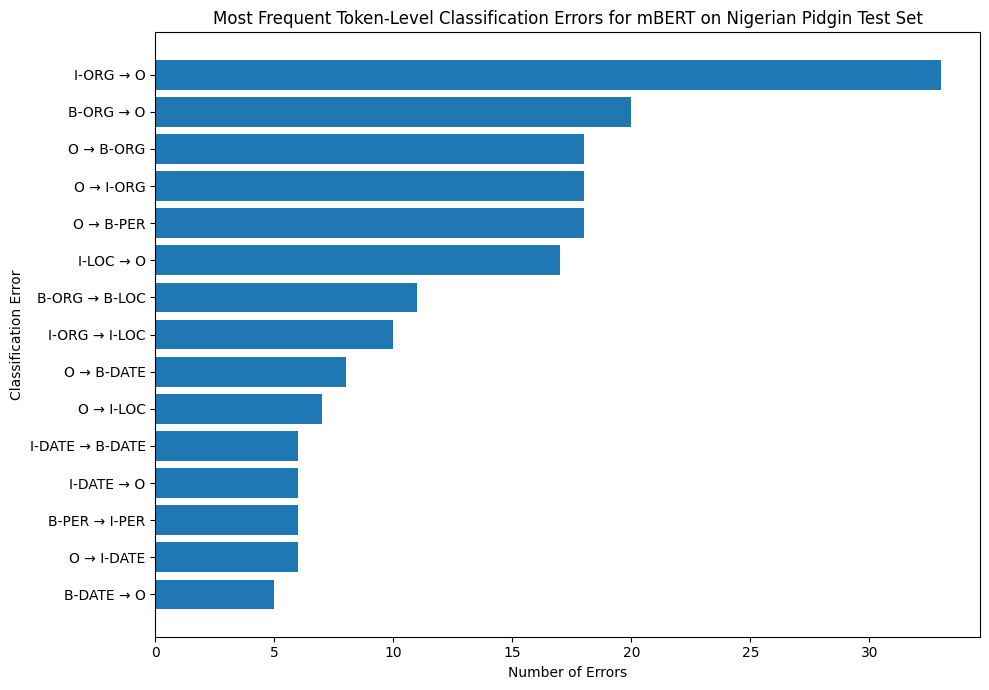

In [ ]:
# Generate the Thesis Figure

import matplotlib.pyplot as plt

# Select the 15 most frequent errors
plot_df = error_df.head(15).copy()

# Reverse order so the most frequent appears at the top
plot_df = plot_df.iloc[::-1]

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Error Type"],
    plot_df["Frequency"]
)

plt.xlabel("Number of Errors")
plt.ylabel("Classification Error")
plt.title(
    "Most Frequent Token-Level Classification Errors "
    "for mBERT on Nigerian Pidgin Test Set"
)

plt.tight_layout()

plt.savefig(
    "mbert_most_frequent_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Entity Level Performance Analysis for mBERT

from sklearn.metrics import classification_report
import numpy as np

# Get predictions from the trained mBERT model
prediction_output = trainer.predict(tokenized_pidgin_test)

# Convert logits to predicted label IDs
predictions = np.argmax(
    prediction_output.predictions,
    axis=-1
)

# True labels
true_labels = prediction_output.label_ids

# Flatten predictions and labels while removing ignored positions
y_true = []
y_pred = []

for true_seq, pred_seq in zip(true_labels, predictions):

    for true_id, pred_id in zip(true_seq, pred_seq):

        # Ignore special/subword tokens
        if true_id == -100:
            continue

        y_true.append(true_id)
        y_pred.append(pred_id)

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(label_names))),
    target_names=label_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           O     0.9935    0.9943    0.9939     14016
       B-PER     0.9197    0.9438    0.9316       267
       I-PER     0.9502    0.9896    0.9695       193
       B-ORG     0.8578    0.8333    0.8454       210
       I-ORG     0.9108    0.8390    0.8734       292
       B-LOC     0.9211    0.9496    0.9351       258
       I-LOC     0.8350    0.7748    0.8037       111
      B-DATE     0.9267    0.9620    0.9440       184
      I-DATE     0.9592    0.9400    0.9495       200

    accuracy                         0.9850     15731
   macro avg     0.9193    0.9141    0.9163     15731
weighted avg     0.9849    0.9850    0.9849     15731



In [ ]:
import numpy as np

# Get the model's prediction logits
logits = prediction_output.predictions

# Convert logits into predicted label IDs
predicted_labels = np.argmax(logits, axis=-1)

# Get the true label IDs
true_labels = prediction_output.label_ids

print("Prediction shape:", predicted_labels.shape)
print("True label shape:", true_labels.shape)

Prediction shape: (600, 92)
True label shape: (600, 92)


In [ ]:
# Flatten the arrays
y_true_flat = true_labels.flatten()
y_pred_flat = predicted_labels.flatten()

# -100 represents tokens that were ignored during evaluation
valid_mask = y_true_flat != -100

y_true_valid = y_true_flat[valid_mask]
y_pred_valid = y_pred_flat[valid_mask]

print("Valid true labels:", len(y_true_valid))
print("Valid predicted labels:", len(y_pred_valid))

Valid true labels: 15731
Valid predicted labels: 15731


### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

label_names = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-DATE",
    "I-DATE"
]

cm = confusion_matrix(
    y_true_valid,
    y_pred_valid,
    labels=list(range(len(label_names)))
)

print("mBERT Confusion Matrix:")
print(cm)

mBERT Confusion Matrix:
[[13936    18     3    18    18     2     7     8     6]
 [    4   252     6     2     0     3     0     0     0]
 [    2     0   191     0     0     0     0     0     0]
 [   20     1     0   175     3    11     0     0     0]
 [   33     0     0     4   245     0    10     0     0]
 [    4     2     1     5     1   245     0     0     0]
 [   17     1     0     0     2     5    86     0     0]
 [    5     0     0     0     0     0     0   177     2]
 [    6     0     0     0     0     0     0     6   188]]


In [ ]:
print(type(true_labels))
print(type(predicted_labels))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
